# Feynman Dataset Analysis for Symbolic Regression

This notebook analyzes the performance of PySR and LaSR (Library-Augmented Symbolic Regression) on the Feynman physics equations dataset.

In [130]:
# Import required libraries
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import json

# Set plot style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

## Load Feynman Equations Metadata

In [131]:
# Load Feynman equations CSV
feynman_df = pd.read_csv('data/FeynmanEquations.csv')

# Display first 10 equations
print("Top 10 Feynman Equations:")
feynman_subset = feynman_df.head(10)
for idx, row in feynman_subset.iterrows():
    print(f"{int(row['Number']):2d}. {row['Filename']:12s} | Formula: {row['Formula']:50s} | Variables: {int(row['# variables'])}")

# Load hints
with open('data/feynman_hints.json', 'r') as f:
    feynman_hints = json.load(f)

print("\nHints loaded for", len(feynman_hints), "equations")

Top 10 Feynman Equations:
 1. I.6.2a       | Formula: exp(-theta**2/2)/sqrt(2*pi)                        | Variables: 1
 2. I.6.2        | Formula: exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma)        | Variables: 2
 3. I.6.2b       | Formula: exp(-((theta-theta1)/sigma)**2/2)/(sqrt(2*pi)*sigma) | Variables: 3
 4. I.8.14       | Formula: sqrt((x2-x1)**2+(y2-y1)**2)                        | Variables: 4
 5. I.9.18       | Formula: G*m1*m2/((x2-x1)**2+(y2-y1)**2+(z2-z1)**2)         | Variables: 9
 6. I.10.7       | Formula: m_0/sqrt(1-v**2/c**2)                              | Variables: 3
 7. I.11.19      | Formula: x1*y1+x2*y2+x3*y3                                  | Variables: 6
 8. I.12.1       | Formula: mu*Nn                                              | Variables: 2
10. I.12.2       | Formula: q1*q2*r/(4*pi*epsilon*r**3)                        | Variables: 4
11. I.12.4       | Formula: q1*r/(4*pi*epsilon*r**3)                           | Variables: 3

Hints loaded for 100 equations


## Define Experiment Configurations

In [132]:
# Define paths
pysr_base_path = "pysr_feynman"
lasr_base_path = "lasr_feynman"



# Color schemes
def generate_gradient_colors(base_color, n_shades):
    """Generate gradient colors from light to dark for a base color."""
    import matplotlib.colors as mcolors
    rgb = mcolors.to_rgb(base_color)
    colors = []
    for i in range(n_shades):
        # Create gradient from light (0.3) to dark (1.0)
        factor = 0.3 + (0.7 * i / (n_shades - 1)) if n_shades > 1 else 1.0
        # Mix with white for lighter shades
        color = tuple(1 - (1 - c) * factor for c in rgb)
        colors.append(mcolors.to_hex(color))
    return colors

# Base colors for methods
pysr_color = generate_gradient_colors('#ff3333', 1)[0]  # Red
lasr_color = generate_gradient_colors('#1f77b4', 1)[0]  # Blue

## Data Extraction Functions

In [138]:
def extract_data_from_summary(file_path):
    """Extract loss, complexity, and predicted equations from a summary file."""
    results = {}
    
    if not os.path.exists(file_path):
        return results
    
    with open(file_path, 'r') as f:
        content = f.read()
    
    # Pattern to extract equation data
    pattern = r'GT Equation #(\d+):\s*(.+?)\nPred Equation #\d+:\s*(.+?)\nScore: ([\d.e+-]+), Loss: ([\d.e+-]+), Complexity: (\d+)'
    matches = re.findall(pattern, content, re.MULTILINE)
    
    for match in matches:
        eq_num = int(match[0])
        gt_equation = match[1].strip()
        pred_equation = match[2].strip()
        score = float(match[3])
        loss = float(match[4])
        complexity = int(match[5])
        
        results[eq_num] = {
            'gt_equation': gt_equation,
            'pred_equation': pred_equation,
            'score': score,
            'loss': loss,
            'complexity': complexity
        }
    
    return results


# Extract data from both methods
pysr_data = extract_data_from_summary(f"{pysr_base_path}/exp_2/summary.txt")
lasr_data = extract_data_from_summary(f"{lasr_base_path}/exp_1/summary.txt")


print(f"PySR data extracted for {len(pysr_data)} equations")
print(f"LaSR data extracted for {len(lasr_data)} equations")

# Get all equation numbers
all_equations = sorted(set(list(pysr_data.keys()) + list(lasr_data.keys())))
print(f"\nTotal unique equations: {len(all_equations)}")
print(f"Equation numbers: {all_equations}")

PySR data extracted for 10 equations
LaSR data extracted for 10 equations

Total unique equations: 10
Equation numbers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


## Create Comparison DataFrame

In [134]:
# Create a comparison dataframe
comparison_data = []

for eq_num in all_equations:
    # Get equation metadata from Feynman dataset
    eq_row = feynman_df[feynman_df['Number'] == eq_num].iloc[0] if eq_num <= len(feynman_df) else None
    
    row = {
        'equation_number': eq_num,
        'equation_name': eq_row['Filename'] if eq_row is not None else f'Equation {eq_num}',
        'formula': eq_row['Formula'] if eq_row is not None else 'Unknown',
        'num_variables': eq_row['# variables'] if eq_row is not None else 0,
        'hint': feynman_hints[eq_num-1] if eq_num-1 < len(feynman_hints) else 'No hint'
    }
    
    # PySR results
    if eq_num in pysr_data:
        row['pysr_loss'] = pysr_data[eq_num]['loss']
        row['pysr_complexity'] = pysr_data[eq_num]['complexity']
        row['pysr_pred'] = pysr_data[eq_num]['pred_equation']
    else:
        row['pysr_loss'] = np.nan
        row['pysr_complexity'] = np.nan
        row['pysr_pred'] = 'Not found'
    
    # LaSR results
    if eq_num in lasr_data:
        row['lasr_loss'] = lasr_data[eq_num]['loss']
        row['lasr_complexity'] = lasr_data[eq_num]['complexity']
        row['lasr_pred'] = lasr_data[eq_num]['pred_equation']
    else:
        row['lasr_loss'] = np.nan
        row['lasr_complexity'] = np.nan
        row['lasr_pred'] = 'Not found'
    
    comparison_data.append(row)

df_comparison = pd.DataFrame(comparison_data)
df_comparison['loss_improvement'] = (df_comparison['pysr_loss'] - df_comparison['lasr_loss']) / df_comparison['pysr_loss'] * 100

# Display summary
print("Comparison Summary:")
print(df_comparison[['equation_name', 'formula', 'num_variables', 'pysr_loss', 'lasr_loss', 'loss_improvement']].to_string(index=False))

Comparison Summary:
equation_name                                              formula  num_variables    pysr_loss    lasr_loss  loss_improvement
       I.6.2a                          exp(-theta**2/2)/sqrt(2*pi)            1.0 1.127628e-04 1.109243e-04      1.630401e+00
        I.6.2          exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma)            2.0 5.053713e-01 4.912006e-01      2.804023e+00
       I.6.2b exp(-((theta-theta1)/sigma)**2/2)/(sqrt(2*pi)*sigma)            3.0 8.284400e-03 4.209831e+02     -5.081537e+06
       I.8.14                          sqrt((x2-x1)**2+(y2-y1)**2)            4.0 1.559017e+04 4.841756e-02      9.999969e+01
       I.9.18           G*m1*m2/((x2-x1)**2+(y2-y1)**2+(z2-z1)**2)            9.0 1.015096e+02 1.067290e+03     -9.514172e+02
       I.10.7                                m_0/sqrt(1-v**2/c**2)            3.0 1.228581e+00 1.055973e-01      9.140494e+01
      I.11.19                                    x1*y1+x2*y2+x3*y3            6.0 9.016822e+00 7.3

## Visualization 1: Loss Comparison Bar Chart

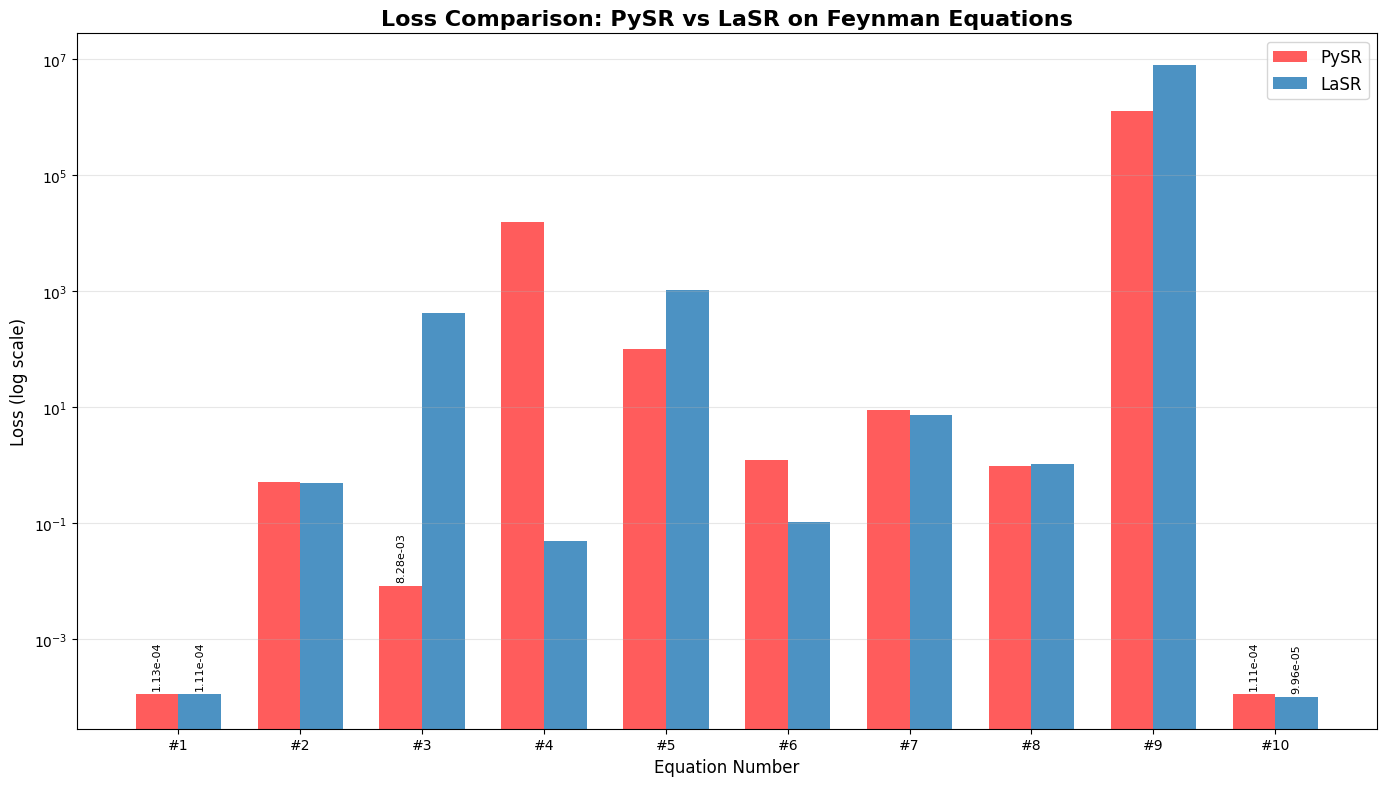

In [135]:
# Create grouped bar chart for loss comparison
fig, ax = plt.subplots(figsize=(14, 8))

# Prepare data
x = np.arange(len(all_equations))
width = 0.35

# Extract losses
pysr_losses = [pysr_data[eq]['loss'] if eq in pysr_data else np.nan for eq in all_equations]
lasr_losses = [lasr_data[eq]['loss'] if eq in lasr_data else np.nan for eq in all_equations]

# Create bars
bars1 = ax.bar(x - width/2, pysr_losses, width, label='PySR', color=pysr_color, alpha=0.8)
bars2 = ax.bar(x + width/2, lasr_losses, width, label='LaSR', color=lasr_color, alpha=0.8)

# Customize plot
ax.set_xlabel('Equation Number', fontsize=12)
ax.set_ylabel('Loss (log scale)', fontsize=12)
ax.set_title('Loss Comparison: PySR vs LaSR on Feynman Equations', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'#{eq}' for eq in all_equations])
ax.set_yscale('log')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
def autolabel(bars, values):
    for bar, val in zip(bars, values):
        if not np.isnan(val) and val < 1e-2:
            height = bar.get_height()
            ax.annotate(f'{val:.2e}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3),
                       textcoords="offset points",
                       ha='center', va='bottom',
                       fontsize=8, rotation=90)

autolabel(bars1, pysr_losses)
autolabel(bars2, lasr_losses)

plt.tight_layout()
plt.show()